# Critical Reproduction Study — Network Intrusion Detection on NSL-KDD

**Course:** Data Science in Cyber (Dr. Uri Itai) · **Topic:** Intrusion Detection Systems (IDS)

**Source under review:** *Network Intrusion Detection Using Machine Learning* — a widely
replicated NSL-KDD classifier tutorial/repository
(`github.com/abhinav-bhardwaj/Network-Intrusion-Detection-Using-Machine-Learning`),
representative of the dominant pattern across NSL-KDD tutorials (see also
`github.com/Mamcose/NSL-KDD-Network-Intrusion-Detection`). These tutorials train
classifiers on **KDDTrain+** with a **random train/test split** and report **~99% accuracy**.

**Claim under test:** *"Machine-learning classifiers detect network intrusions on NSL-KDD with ~99% accuracy."*

**Our thesis:** that number is an artefact of (a) evaluating on a *random split of one
distribution* instead of the official **KDDTest+** (which the dataset authors built with
novel attacks), and (b) using **Accuracy** on **imbalanced** data. Under a correct protocol the
same models collapse to **~75–80%** accuracy, with near-zero recall on the rarest, most
dangerous attacks (R2L, U2R). This notebook generates the evidence end-to-end.

> Reference: Tavallaee, Bagheri, Lu & Ghorbani (2009), *A Detailed Analysis of the KDD CUP 99 Data Set*, IEEE CISDA.

In [1]:
from __future__ import annotations
import json
import sys
import warnings
from pathlib import Path

import matplotlib
# Inside Jupyter we keep the inline backend so every figure renders in the notebook;
# when this file is run as a plain script we switch to the headless Agg backend.
try:
    get_ipython()  # type: ignore  # noqa: F821
except NameError:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

# make the local src/ package importable whether run from repo root or notebooks/
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src import data, eda, evaluate, features, models  # noqa: E402

warnings.filterwarnings("ignore")
# `display` is provided by IPython inside the notebook; this shim lets the same
# file also run as a plain script (e.g. for CI / smoke testing).
try:
    display  # type: ignore  # noqa: B018
except NameError:
    def display(obj):  # noqa: D401
        print(obj)

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120, "display.max_columns", 60)
RANDOM_STATE = models.RANDOM_STATE
RESULTS: dict = {}  # everything quantitative is collected here and dumped to JSON
(ROOT / "results").mkdir(exist_ok=True)
print("repo root:", ROOT)

repo root: /mnt/c/DataCyber


## 1. Data Loading & Inspection

NSL-KDD ships as headerless CSVs. We attach the canonical 41-feature schema plus the two
trailing columns: the fine-grained `label` and a `difficulty` score. We derive a binary
target (`is_attack`) and the standard 5-class target (`attack_category`).

In [2]:
train, test = data.load_train_test(ROOT / "data" / "raw")
print("KDDTrain+:", train.shape, "| KDDTest+:", test.shape)
ov_tr, ov_te = eda.basic_overview(train), eda.basic_overview(test)
RESULTS["overview_train"], RESULTS["overview_test"] = ov_tr, ov_te
display(pd.DataFrame({"KDDTrain+": ov_tr, "KDDTest+": ov_te}))

KDDTrain+: (125973, 46) | KDDTest+: (22544, 46)


,KDDTrain+,KDDTest+
n_rows,125973,22544
n_cols,46,46
dtype_counts,"{'int64': 25, 'float64': 15, 'str': 6}","{'int64': 25, 'float64': 15, 'str': 6}"
total_missing,0,0
duplicate_rows,0,0


In [3]:
# Feature dtypes
print("Feature dtype counts (model inputs only):")
print(data.feature_matrix(train).dtypes.value_counts())
train.head(3)

Feature dtype counts (model inputs only):
int64      23
float64    15
str         3
Name: count, dtype: int64


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,attack_category,is_attack,binary_label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.0,0.0,0.0,0.0,1.00,0.00,0.0,150,25,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20,normal,0,normal
1,0,udp,other,SF,146,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,1,0.0,0.0,0.0,0.0,0.08,0.15,0.0,255,1,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15,normal,0,normal
2,0,tcp,private,S0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,123,6,1.0,1.0,0.0,0.0,0.05,0.07,0.0,255,26,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19,DoS,1,attack


### 1.1 Do the column & index names make sense?

* The **index** is a meaningless `RangeIndex` (no event id / no timestamp) — correct to leave as-is.
* Column names are sensible once attached. **Two columns are NOT model features:**
  * `difficulty` — NSL-KDD *metadata* (how many of 21 baseline learners got the row right).
    It is unavailable at inference time, and it is **correlated with the label** → using it as a
    feature is **target leakage**. We exclude it (it is not in `FEATURE_COLUMNS`). Many tutorials
    leave it in.
  * `label` — the raw target.

In [4]:
# Demonstrate the leakage risk of the 'difficulty' column: it differs by class.
leak = train.groupby("is_attack")["difficulty"].mean().rename({0: "normal", 1: "attack"})
print("Mean 'difficulty' by class (should differ -> leaky if used as a feature):")
print(leak.round(3))
RESULTS["difficulty_leak"] = {k: float(v) for k, v in leak.items()}

Mean 'difficulty' by class (should differ -> leaky if used as a feature):
is_attack
normal    20.316
attack    18.572
Name: difficulty, dtype: float64


### 1.2 Missing values, duplicates, constant & duplicate features

In [5]:
print("Total missing (train):", train.isna().sum().sum(), "| (test):", test.isna().sum().sum())
print("Duplicate rows (train):", int(train.duplicated().sum()),
      "| (test):", int(test.duplicated().sum()),
      "  <- NSL-KDD removed the KDD'99 duplicate-record bias")
const = eda.constant_features(train, data.FEATURE_COLUMNS)
dup_pairs = eda.duplicate_feature_pairs(train, data.FEATURE_COLUMNS)
print("Constant (zero-variance) features:", const)
print("Exact duplicate feature pairs:", dup_pairs)
RESULTS["constant_features"] = const
RESULTS["duplicate_feature_pairs"] = dup_pairs

Total missing (train): 0 | (test): 0


Duplicate rows (train): 0 | (test): 0   <- NSL-KDD removed the KDD'99 duplicate-record bias


Constant (zero-variance) features: ['num_outbound_cmds']
Exact duplicate feature pairs: []


**Finding.** `num_outbound_cmds` is constant (all zeros) across all 126k rows — zero information.
It must be dropped (done automatically by `features.feature_groups`). There are no missing values
and essentially no duplicate rows (an NSL-KDD design improvement over KDD'99).

### 1.3 Temporal analysis — does it align with world knowledge?

NSL-KDD has **no timestamp and no event ordering**. The only time-like feature is `duration`
(connection length in seconds). So genuine time-series analysis (hour-of-day, day-of-week,
drift over wall-clock time) is **impossible** on this dataset — an honest limitation that the
tutorials never state. The "temporal" dimension that *does* matter here is the
**train → test distribution shift** (a *concept-drift* analogue), which we quantify next.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Class balance & prevalence — and the train↔test shift

Prevalence is the real-world base rate of each class. It tells us (i) Accuracy is dangerous here
and (ii) whether the train and test sets even describe the same world.

                KDDTrain+                KDDTest+               
                    count prevalence_pct    count prevalence_pct
attack_category                                                 
normal              67343         53.458     9711         43.076
DoS                 45927         36.458     7460         33.091
Probe               11656          9.253     2421         10.739
R2L                   995          0.790     2885         12.797
U2R                    52          0.041       67          0.297


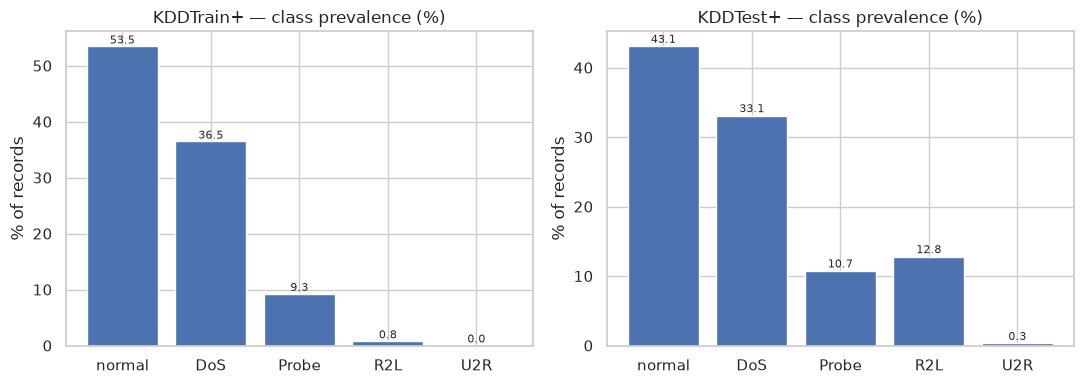

In [6]:
prev_tr = eda.class_prevalence(train, "attack_category").reindex(data.CLASS_ORDER)
prev_te = eda.class_prevalence(test, "attack_category").reindex(data.CLASS_ORDER)
combined = pd.concat({"KDDTrain+": prev_tr, "KDDTest+": prev_te}, axis=1)
RESULTS["prevalence"] = json.loads(combined.to_json())
eda.plot_class_balance(train, test, "attack_category", data.CLASS_ORDER)
print(combined)

**Finding (the smoking gun).** The class mix is *not* stationary:
R2L rises from **0.79% → 12.8%** and U2R from **0.04% → 0.30%** between train and test, while the
binary attack rate moves 46.5% → 56.9%. KDDTest+ deliberately over-represents the hard
remote/elevation attacks that models barely see in training. Any model tuned on the train
distribution is being asked a *different question* at test time — this is the core reason
random-split accuracy does not transfer.

**Real-world meaning & did the authors address it?** Prevalence is the attack *base rate* a SOC
faces; with U2R at 0.04% of training rows (52 samples) the learner sees almost no examples of the
most damaging attack. **The reviewed tutorials do not address this**: they report a single
Accuracy number, use no resampling/class weights, and never inspect per-class prevalence — so the
imbalance silently dominates the result. There is effectively a **sampling problem** in U2R/R2L
(too few positives to learn a stable boundary), which §5.4 probes directly.

### 2.2 Feature distributions & robust outlier analysis

Cyber traffic features are heavy-tailed. We compare a classic **Z-score** outlier count with the
robust **IQR** and **MAD / Modified-Z** rules. Under heavy skew, Z-score and the mean are
distorted by extreme values, so MAD/IQR (and the median) are the honest choices.

Outlier counts by method (note how Z-score under-counts under extreme skew):


,skew,z_gt3,iqr_out,mad_gt3p5,max,median,mean
feature,,,,,,,
src_bytes,190.67,11,13840,31784,1.379964e+09,44.0,45566.74
dst_bytes,290.05,3,23579,0,1.309937e+09,0.0,19779.11
duration,11.88,1431,10018,0,4.290800e+04,0.0,287.14
count,1.51,2661,3157,45760,5.110000e+02,14.0,84.11
srv_count,4.69,3259,12054,11687,5.110000e+02,8.0,27.74
dst_host_count,-0.83,0,0,0,2.550000e+02,255.0,182.15


log1p collapses the skew that inflates Z-score outliers.


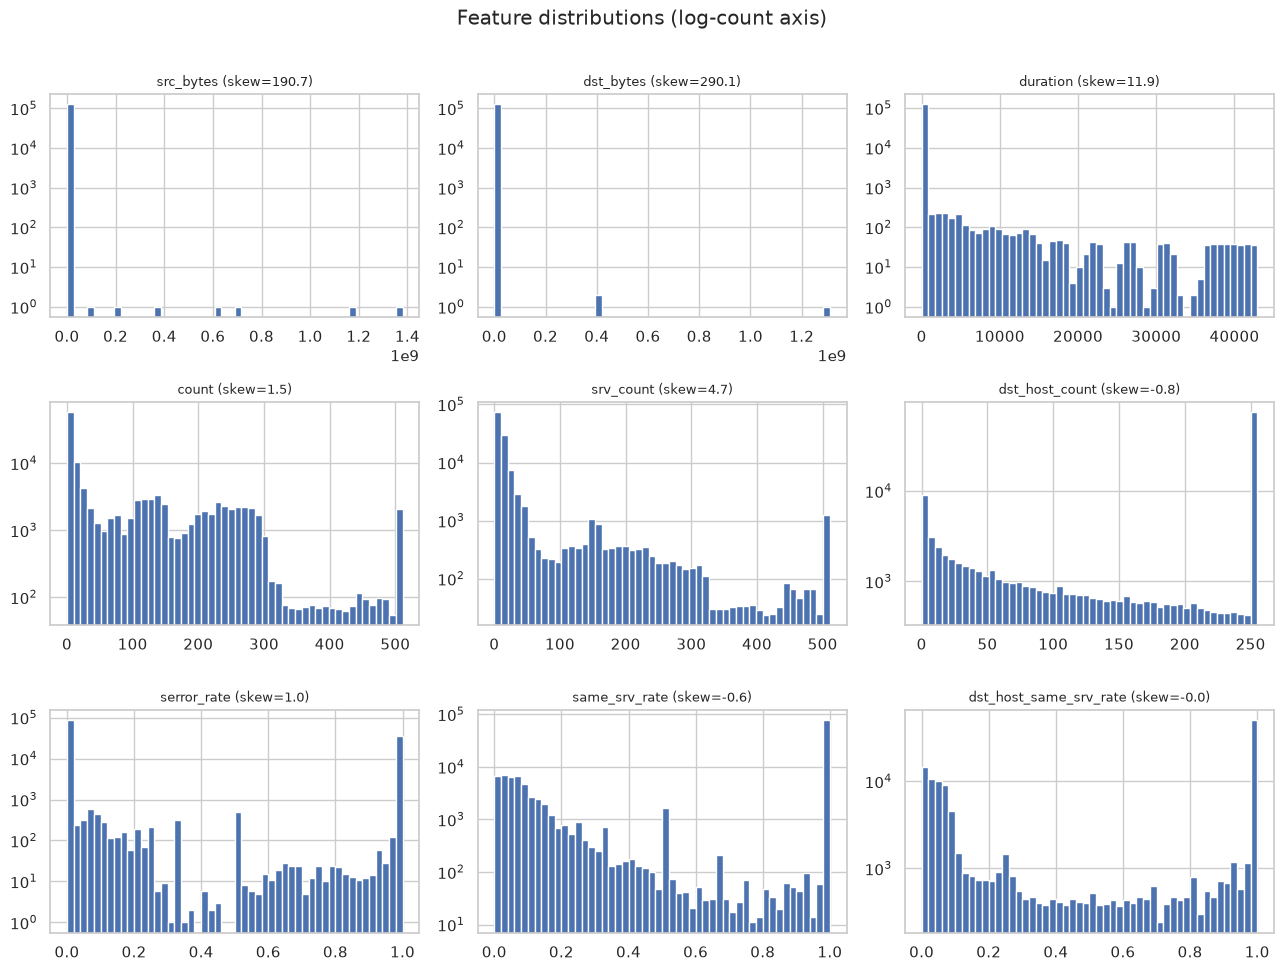

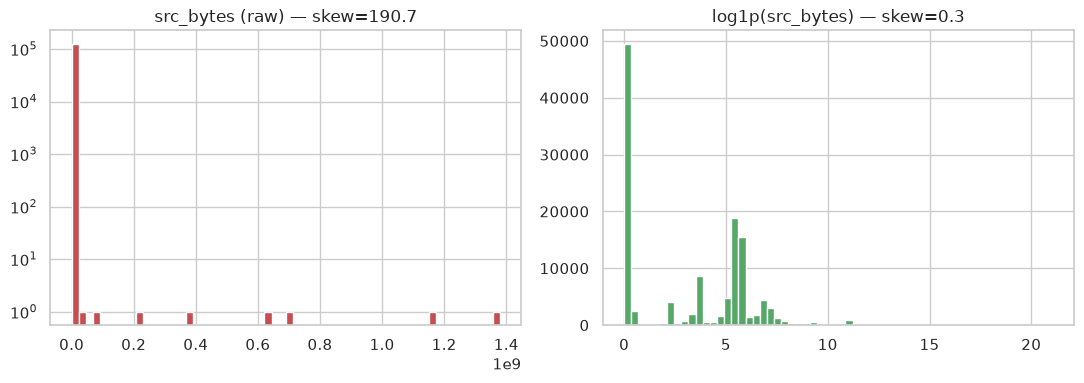

In [7]:
skewed = ["src_bytes", "dst_bytes", "duration", "count", "srv_count", "dst_host_count"]
# Distributions of a representative feature set (counts/bytes + a bounded rate).
eda.plot_feature_distributions(
    train, skewed + ["serror_rate", "same_srv_rate", "dst_host_same_srv_rate"])
out_tbl = pd.DataFrame([eda.outlier_summary(train[c]) for c in skewed]).set_index("feature")
RESULTS["outlier_summary"] = json.loads(out_tbl.to_json())
print("Outlier counts by method (note how Z-score under-counts under extreme skew):")
display(out_tbl.round(2))
eda.plot_log_transform_effect(train, "src_bytes")
print("log1p collapses the skew that inflates Z-score outliers.")

**Finding.** The byte/count features are extremely right-skewed — `src_bytes` has skew ≈ 191 and
spans 0 to 1.3e9. The robust methods agree the spread is huge (IQR flags ~13,840 and MAD ~31,784
`src_bytes` outliers) while the classic **Z-score flags only 11** — because a handful of giant
values inflate the standard deviation and *mask* the very outliers it is meant to find. This is the
textbook case for **MAD/IQR over Z-score** and for the `log1p` transform applied in §3.

### 2.3 Correlation analysis — which coefficient, and why

We use **Spearman** rank correlation as the primary measure. Justification:
* **Pearson** assumes *linear* relationships between *continuous, roughly-normal* variables and is
  highly sensitive to the extreme outliers we just documented — inappropriate for these tails.
* **Spearman** measures *monotonic* association on ranks, so it is robust to outliers and the
  non-normal, heavy-tailed shapes typical of counts/bytes — the right tool here.
* **Kendall** also ranks but is most useful for small samples / many ties; with 126k rows
  Spearman is the pragmatic choice.

We care about correlation here to find **redundancy** (features carrying the same information),
which both hurts model interpretability (importance gets split across collinear features) and
wastes capacity.

Highly correlated (|Spearman| >= 0.9) feature pairs -> redundancy candidates:


,feat_a,feat_b,corr
761,serror_rate,srv_serror_rate,0.973
837,rerror_rate,srv_rerror_rate,0.966
811,srv_serror_rate,dst_host_srv_serror_rate,0.942
773,serror_rate,dst_host_serror_rate,0.936
774,serror_rate,dst_host_srv_serror_rate,0.922
913,same_srv_rate,diff_srv_rate,-0.920
1255,dst_host_serror_rate,dst_host_srv_serror_rate,0.919
1065,dst_host_srv_count,dst_host_same_srv_rate,0.919
810,srv_serror_rate,dst_host_serror_rate,0.919


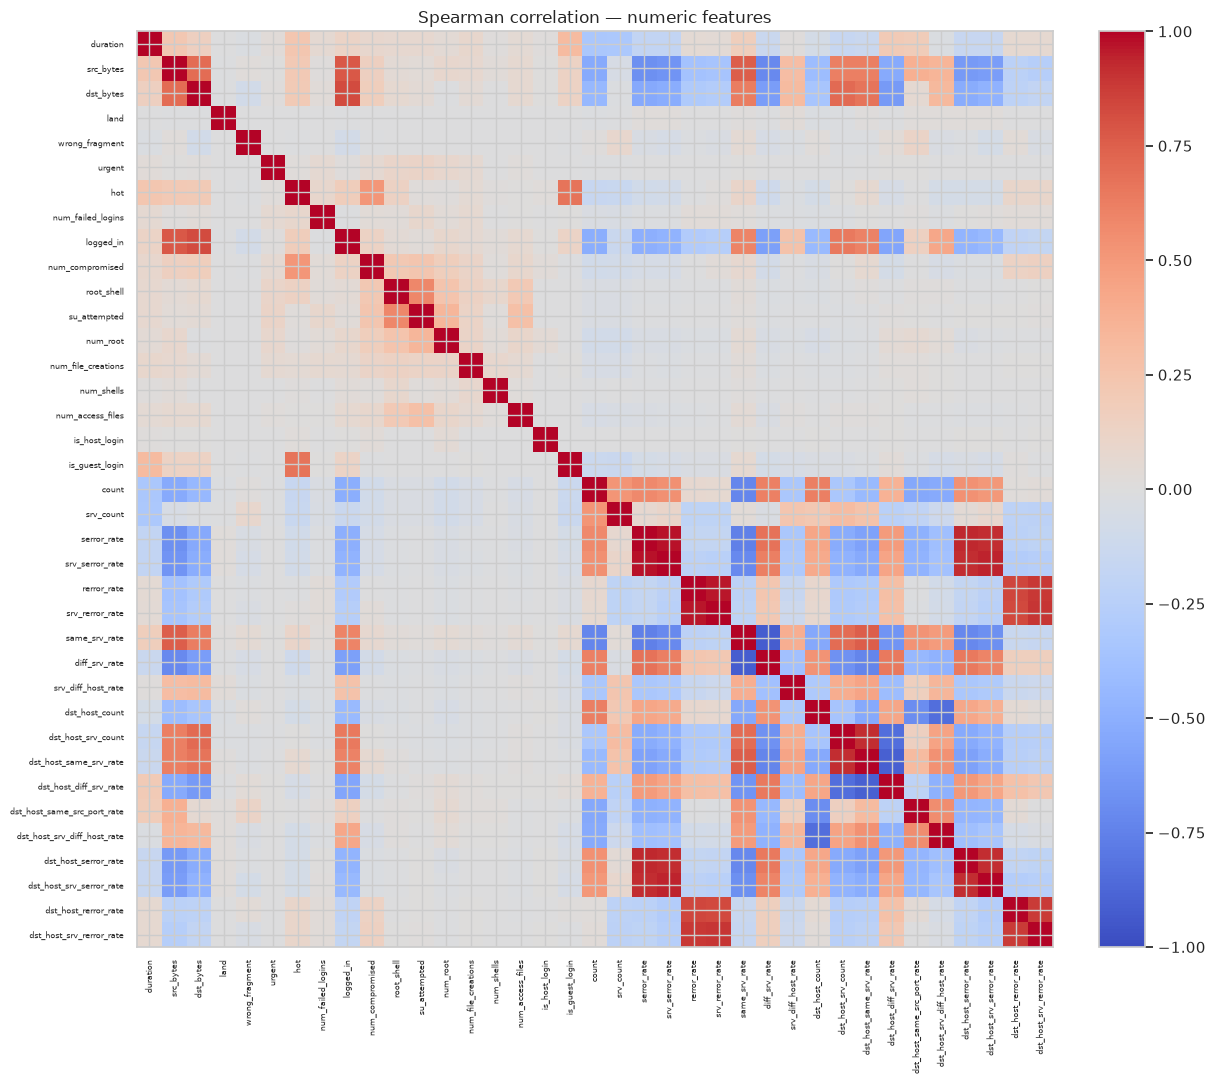

In [8]:
numeric_feats = [c for c in data.FEATURE_COLUMNS
                 if c not in data.CATEGORICAL_COLUMNS and c not in const]
corr = eda.correlation_matrix(train, numeric_feats, method="spearman")
eda.plot_correlation_heatmap(corr)
red_pairs = eda.high_correlation_pairs(corr, threshold=0.9)
RESULTS["redundant_pairs"] = red_pairs.round(3).to_dict("records")
print("Highly correlated (|Spearman| >= 0.9) feature pairs -> redundancy candidates:")
display(red_pairs.round(3))

**Finding.** Several `*_serror_rate`, `*_srv_rate`, and `dst_host_*` features are near-duplicates
(|ρ| ≥ 0.9). Redundancy detection (here: rank correlation; alternatives: VIF, mutual information,
exact-duplicate check) lets us prune or combine them — improving interpretability without losing
signal.

**Statistical vs practical significance.** With n = 125,973, *every* correlation is "statistically
significant" (p ≈ 0), so a p-value tells us nothing useful here. We therefore select on **effect
size** (|ρ| ≥ 0.9) — the threshold at which redundancy is large enough to matter practically. This
distinction is essential in cyber data, where huge sample sizes make trivial correlations look
"significant".

### 2.4 Crosstab / group-by — protocol × attack family

In [9]:
ct = pd.crosstab(train["protocol_type"], train["attack_category"])
RESULTS["crosstab_protocol"] = json.loads(ct.to_json())
print(ct)

attack_category    DoS  Probe  R2L  U2R  normal
protocol_type                                  
icmp              2847   4135    0    0    1309
tcp              42188   5857  995   49   53600
udp                892   1664    0    3   12434


**Finding.** Attack families are highly protocol-dependent (DoS dominates `icmp`/`tcp`; most R2L
rides `tcp`). This is exactly the kind of structure a `protocol_type` one-hot feature should
capture — and a reason ordinal/label-encoding it (as some tutorials do) is wrong: there is no
natural order among tcp/udp/icmp.

## 3. Feature Engineering (leakage-safe)

All transforms live inside a scikit-learn `ColumnTransformer` and are **fit on training data only**:
* **drop** constant `num_outbound_cmds`;
* **log1p + StandardScaler** on the 16 heavy-tailed count/byte features;
* **StandardScaler** on the bounded rate features;
* **One-Hot** (`handle_unknown='ignore'`) on `protocol_type`, `service`, `flag` — defends against
  unseen `service` categories at test time, unlike label/ordinal encoding.

In [10]:
groups = features.feature_groups(train)
preprocessor = features.build_preprocessor(groups)
# Fit on train only, just to report the output dimensionality:
_ = preprocessor.fit(data.feature_matrix(train), train["is_attack"])
n_out = preprocessor.transform(data.feature_matrix(train.head(5))).shape[1]
RESULTS["feature_groups"] = {k: (v if k == "dropped" else len(v)) for k, v in groups.items()}
RESULTS["n_model_features"] = int(n_out)
print("Feature groups:", {k: (v if k == 'dropped' else len(v)) for k, v in groups.items()})
print("Model input dimensionality after encoding:", n_out)

Feature groups: {'dropped': ['num_outbound_cmds'], 'categorical': 3, 'log_numeric': 16, 'plain_numeric': 21}
Model input dimensionality after encoding: 121


### 3.1 Feature selection (what we dropped, and why)

Selection here is principled, not blind: we remove the **1 constant** feature (`num_outbound_cmds`),
we keep the `difficulty` metadata **out** of the model (leakage, §1.1), and we *flag* the 9 redundant
pairs (§2.3) as merge/drop candidates. We keep the encoded one-hot columns because tree ensembles
handle them well and they carry the protocol/service structure seen in the crosstab.

In [11]:
# Feature CREATION: domain features proposed in the report (kept separate from the baseline pipeline
# so the controlled A/B comparison stays clean). Shown here to demonstrate the idea concretely.
engineered = features.add_engineered_features(train)[
    ["src_bytes", "dst_bytes", "total_bytes", "bytes_ratio", "error_rate_mean", "is_attack"]
].head()
print("Examples of created features (total_bytes / bytes_ratio / error_rate_mean):")
display(engineered)

Examples of created features (total_bytes / bytes_ratio / error_rate_mean):


,src_bytes,dst_bytes,total_bytes,bytes_ratio,error_rate_mean,is_attack
0,491,0,491,492.000000,0.0,0
1,146,0,146,147.000000,0.0,0
2,0,0,0,1.000000,0.5,1
3,232,8153,8385,0.028575,0.1,0
4,199,420,619,0.475059,0.0,0


### 3.2 Dimensionality reduction — PCA for visualisation

We do **not** feed PCA to the models (121 encoded features is small, and trees are unharmed by
correlated inputs), but a 2-component PCA is a useful *visual* check of class separability — and it
previews our central finding.

PCA: DoS/Probe form separable structure; R2L/U2R sit on top of 'normal' -> a visual preview of why they are so hard to detect.


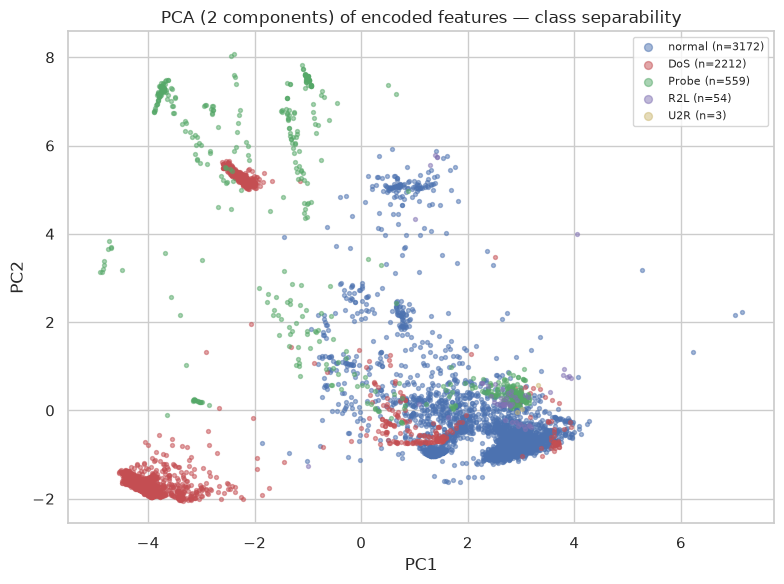

In [12]:
eda.plot_pca_2d(train, preprocessor, "attack_category", data.CLASS_ORDER)
print("PCA: DoS/Probe form separable structure; R2L/U2R sit on top of 'normal' "
      "-> a visual preview of why they are so hard to detect.")

## 4. Model Training — the controlled experiment

We hold **everything** constant (features, preprocessing, models, seeds) and vary **only the
evaluation protocol**:

* **Protocol A (tutorial-style):** random stratified 80/20 split of KDDTrain+; evaluate on the
  held-out 20% — same distribution as training.
* **Protocol B (correct):** train on *all* of KDDTrain+; evaluate on the official **KDDTest+**.

Models: a majority-class **baseline**, **Logistic Regression**, **Random Forest**, **Gradient
Boosting**. Binary target (attack vs normal) first, then 5-class.

In [13]:
def fit_eval_binary(models_dict, X_tr, y_tr, X_ev, y_ev):
    """Fit each pipeline on (X_tr,y_tr); return binary metrics + scores on (X_ev,y_ev)."""
    res, scores = {}, {}
    for name, mdl in models_dict.items():
        mdl.fit(X_tr, y_tr)
        y_pred = mdl.predict(X_ev)
        y_score = (mdl.predict_proba(X_ev)[:, 1]
                   if hasattr(mdl, "predict_proba") else None)
        res[name] = evaluate.binary_metrics(y_ev, y_pred, y_score)
        scores[name] = y_score
    return res, scores

Xtr_full, ytr_bin = data.feature_matrix(train), train["is_attack"].to_numpy()
Xte_full, yte_bin = data.feature_matrix(test), test["is_attack"].to_numpy()

# Protocol A — random split of KDDTrain+ (mimics the tutorials)
Xa_tr, Xa_ev, ya_tr, ya_ev = train_test_split(
    Xtr_full, ytr_bin, test_size=0.20, random_state=RANDOM_STATE, stratify=ytr_bin)
protoA, _ = fit_eval_binary(make := models.make_models(features.build_preprocessor(groups)),
                            Xa_tr, ya_tr, Xa_ev, ya_ev)

# Protocol B — official KDDTest+
protoB, scoresB = fit_eval_binary(models.make_models(features.build_preprocessor(groups)),
                                  Xtr_full, ytr_bin, Xte_full, yte_bin)

RESULTS["binary_protocolA_randomsplit"] = protoA
RESULTS["binary_protocolB_official_test"] = protoB
print("done")

done


### 4.1 Cross-validation sanity check (still optimistic)

To rule out "it was just a lucky split", we run 5-fold stratified CV *within* KDDTrain+. It also
reports ~0.99 — confirming the inflation is caused by the **train/test distribution being the
same**, not by one fortunate split.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rf_cv = models.make_models(features.build_preprocessor(groups))["Random Forest"]
cv_acc = cross_val_score(rf_cv, Xtr_full, ytr_bin, cv=cv, scoring="accuracy", n_jobs=-1)
RESULTS["rf_cv_accuracy_mean"] = float(cv_acc.mean())
RESULTS["rf_cv_accuracy_std"] = float(cv_acc.std())
print(f"Random Forest 5-fold CV accuracy on KDDTrain+: {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")

Random Forest 5-fold CV accuracy on KDDTrain+: 0.9989 ± 0.0002


## 5. Evaluation

### 5.1 The headline result: Protocol A vs Protocol B

Every metric for the **same Random Forest**, changing only the test data.

In [15]:
tblA = evaluate.metrics_table(protoA)
tblB = evaluate.metrics_table(protoB)
print("PROTOCOL A — random split of KDDTrain+ (what tutorials report):")
display(tblA)
print("\nPROTOCOL B — official KDDTest+ (correct evaluation):")
display(tblB)
gap = (tblA.loc["Random Forest", "accuracy"] - tblB.loc["Random Forest", "accuracy"])
RESULTS["rf_accuracy_gap_A_minus_B"] = float(gap)
print(f"\nRandom Forest accuracy drop A→B: {gap*100:.1f} percentage points")

PROTOCOL A — random split of KDDTrain+ (what tutorials report):


,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,pr_auc
Baseline (majority),0.5346,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.4654
Logistic Regression,0.9839,0.9836,0.9854,0.9799,0.9826,0.9810,0.9676,0.9978,0.9980
Random Forest,0.9990,0.9990,0.9995,0.9985,0.9990,0.9987,0.9981,1.0000,1.0000
Gradient Boosting,0.9994,0.9993,0.9996,0.9991,0.9993,0.9992,0.9987,1.0000,1.0000



PROTOCOL B — official KDDTest+ (correct evaluation):


,accuracy,balanced_accuracy,precision,recall,f1,f2,mcc,roc_auc,pr_auc
Baseline (majority),0.4308,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.5692
Logistic Regression,0.7446,0.7664,0.9134,0.6091,0.7308,0.6525,0.5436,0.7935,0.8579
Random Forest,0.7798,0.8033,0.9689,0.6335,0.7661,0.6806,0.6214,0.9614,0.9640
Gradient Boosting,0.8032,0.8237,0.9693,0.6757,0.7963,0.7193,0.6552,0.9610,0.9662



Random Forest accuracy drop A→B: 21.9 percentage points


### 5.2 Metric definitions and why they matter in IDS

| Metric | Definition | Why it matters for intrusion detection |
|---|---|---|
| Accuracy | (TP+TN)/N | Misleading under imbalance — a constant predictor scores high. |
| Balanced Acc. | mean of per-class recall | Treats rare attacks as equally important as `normal`. |
| Precision | TP/(TP+FP) | High precision = few false alarms (analyst fatigue). |
| Recall (TPR) | TP/(TP+FN) | High recall = few **missed attacks** — the costly error. |
| F1 / Fβ | harmonic mean (β=2 up-weights recall) | Single number; Fβ encodes that a miss > a false alarm. |
| MCC | balanced correlation over the confusion matrix | Trustworthy single score even with heavy imbalance. |
| ROC-AUC / PR-AUC | ranking quality; PR-AUC vs the prevalence baseline | PR-AUC is the honest curve when positives are rare. |

We **down-weight raw Accuracy** and lead with MCC, Balanced Accuracy, PR-AUC and per-class recall.

A trivial majority predictor scores accuracy = 0.569 on KDDTest+.


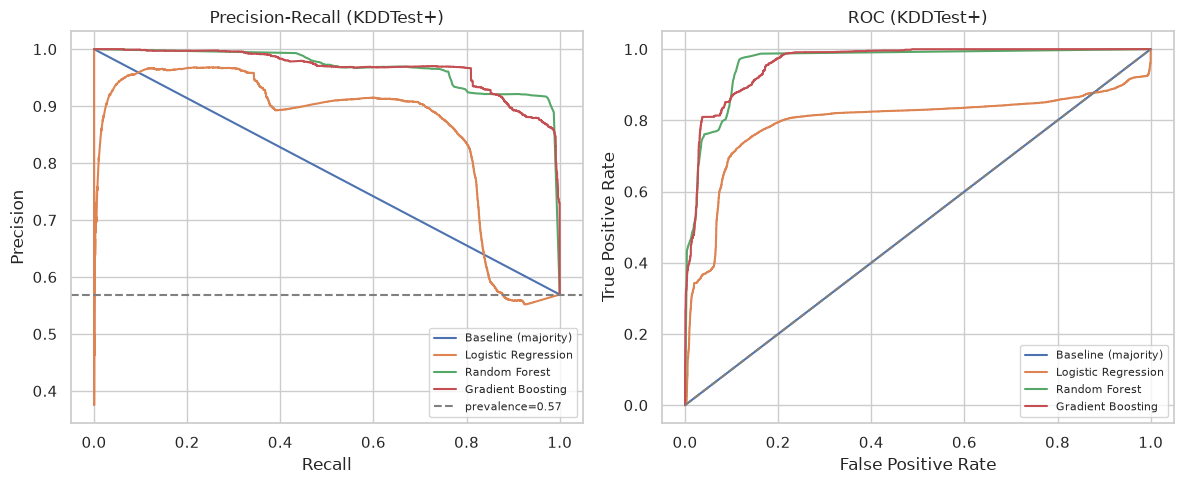

In [16]:
# PR / ROC curves on KDDTest+, and the prevalence baseline for Accuracy honesty.
curves = {name: (yte_bin, s) for name, s in scoresB.items() if s is not None}
evaluate.plot_pr_and_roc(curves)
base_rate = float(max(np.mean(yte_bin), 1 - np.mean(yte_bin)))
RESULTS["majority_baseline_accuracy_test"] = base_rate
print(f"A trivial majority predictor scores accuracy = {base_rate:.3f} on KDDTest+.")

### 5.3 Multiclass evaluation & per-class recall (where Accuracy hides the failure)

Multiclass metrics on KDDTest+:


,accuracy,balanced_accuracy,macro_f1,weighted_f1,mcc
Baseline (majority),0.4308,0.2000,0.1204,0.2594,0.0000
Logistic Regression,0.7397,0.5124,0.5178,0.6994,0.6173
Random Forest,0.7531,0.4937,0.5083,0.7122,0.6442
Gradient Boosting,0.7791,0.5626,0.5614,0.7447,0.6788



Per-class RECALL on KDDTest+ (note R2L / U2R):


,Baseline (majority),Logistic Regression,Random Forest,Gradient Boosting
normal,1.0,0.923,0.974,0.968
DoS,0.0,0.796,0.791,0.836
Probe,0.0,0.698,0.610,0.672
R2L,0.0,0.025,0.050,0.098
U2R,0.0,0.119,0.045,0.239


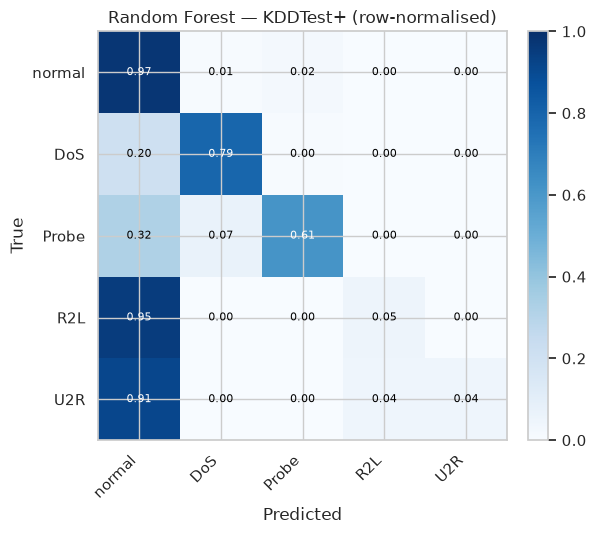

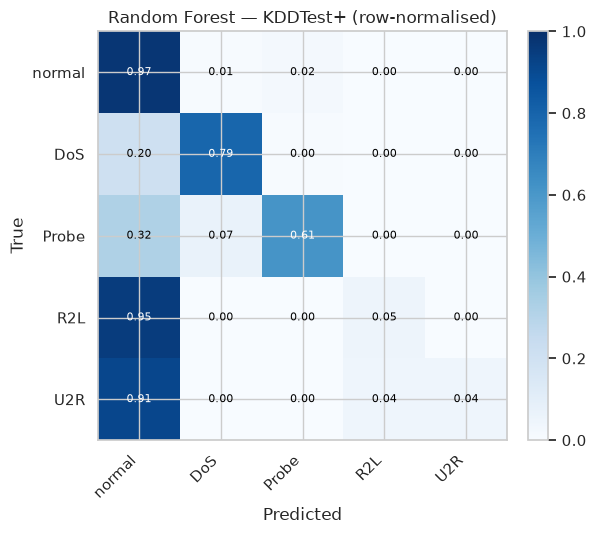

In [17]:
ytr_mc, yte_mc = train["attack_category"].to_numpy(), test["attack_category"].to_numpy()
mc_models = models.make_models(features.build_preprocessor(groups))
mc_metrics, per_class = {}, {}
best_name, best_pred = None, None
for name, mdl in mc_models.items():
    mdl.fit(Xtr_full, ytr_mc)
    pred = mdl.predict(Xte_full)
    mc_metrics[name] = evaluate.multiclass_metrics(yte_mc, pred)
    per_class[name] = evaluate.per_class_recall(yte_mc, pred, data.CLASS_ORDER)
    if name == "Random Forest":
        best_name, best_pred = name, pred
RESULTS["multiclass_protocolB"] = mc_metrics
recall_tbl = pd.DataFrame(per_class).round(3)
RESULTS["per_class_recall"] = json.loads(recall_tbl.to_json())
print("Multiclass metrics on KDDTest+:"); display(evaluate.metrics_table(mc_metrics))
print("\nPer-class RECALL on KDDTest+ (note R2L / U2R):"); display(recall_tbl)
evaluate.plot_confusion(yte_mc, best_pred, data.CLASS_ORDER,
                        "Random Forest — KDDTest+ (row-normalised)", "confusion_rf_test.png")

### 5.4 Can the rare-class failure be fixed? Cost-sensitive re-weighting

The textbook remedy for imbalance is to make rare-class errors more expensive
(`class_weight='balanced'`). We retrain Random Forest and Gradient Boosting with balanced weights
and compare per-class recall. This tests whether the R2L/U2R blindness is *merely* imbalance — or
something deeper that re-weighting cannot fix.

In [18]:
bal_models = models.make_models(features.build_preprocessor(groups), class_weight="balanced")
bal_recall = {}
for name in ["Random Forest", "Gradient Boosting"]:
    bal_models[name].fit(Xtr_full, ytr_mc)
    pred = bal_models[name].predict(Xte_full)
    bal_recall[f"{name} (balanced)"] = evaluate.per_class_recall(yte_mc, pred, data.CLASS_ORDER)
compare_recall = pd.concat(
    [pd.DataFrame(per_class)[["Random Forest", "Gradient Boosting"]],
     pd.DataFrame(bal_recall)], axis=1).round(3)
RESULTS["cost_sensitive_recall"] = json.loads(compare_recall.to_json())
print("Per-class recall — default vs class_weight='balanced' (KDDTest+):")
display(compare_recall)

Per-class recall — default vs class_weight='balanced' (KDDTest+):


,Random Forest,Gradient Boosting,Random Forest (balanced),Gradient Boosting (balanced)
normal,0.974,0.968,0.973,0.971
DoS,0.791,0.836,0.762,0.784
Probe,0.610,0.672,0.638,0.737
R2L,0.050,0.098,0.016,0.277
U2R,0.045,0.239,0.090,0.209


**Finding.** Balanced re-weighting helps **unevenly and only partially**: Gradient Boosting's R2L
recall rises (≈0.10 → ≈0.28) while Random Forest's R2L recall actually *drops* — and **both still
miss the large majority of R2L/U2R**. This is decisive: the failure is **not just an imbalance
artefact** but a combination of (i) the train→test distribution shift and (ii) R2L/U2R being nearly
inseparable from normal traffic at the flow-statistics level. A genuine fix needs different signals
(payload/host telemetry) or a different paradigm (dedicated anomaly detection) — not merely a
heavier class weight. An important, non-obvious conclusion that the original tutorials never reach.

## 6. Error Analysis

### 6.1 Where the models fail

In [19]:
err = pd.DataFrame(per_class)["Random Forest"]
RESULTS["rf_R2L_recall"] = float(err["R2L"]); RESULTS["rf_U2R_recall"] = float(err["U2R"])
print("Random Forest recall by class on KDDTest+:")
print(err.round(3))
print("\nInterpretation: DoS/Probe/normal are detected well; R2L and U2R — the attacks that "
      "matter most (credential theft, privilege escalation) — are largely MISSED.")

Random Forest recall by class on KDDTest+:
normal    0.974
DoS       0.791
Probe     0.610
R2L       0.050
U2R       0.045
Name: Random Forest, dtype: float64

Interpretation: DoS/Probe/normal are detected well; R2L and U2R — the attacks that matter most (credential theft, privilege escalation) — are largely MISSED.


**Pattern.** Errors concentrate in the **rare, content-based** attacks (R2L/U2R) that look almost
identical to normal traffic at the packet-statistics level and are **under-represented in training**
(52 U2R rows) yet **over-represented in test**. This is the FN-heavy failure mode that headline
accuracy conceals.

### 6.2 False Positive / False Negative trade-off (operating point)

In IDS a **False Negative** (missed intrusion) is usually far costlier than a **False Positive**
(false alarm), but too many false alarms cause alert fatigue. The decision threshold is a lever.

In [20]:
rf_scoreB = scoresB["Random Forest"]
sweep = evaluate.threshold_sweep(yte_bin, rf_scoreB)
RESULTS["threshold_sweep"] = sweep.round(4).to_dict("records")
display(sweep)
print("Lowering the threshold trades more false alarms (FP) for fewer missed attacks (FN).")

,threshold,precision,recall,f2,false_alarms_FP,missed_attacks_FN
0,0.1,0.921263,0.852490,0.865410,935,1893
1,0.2,0.932682,0.780566,0.806886,723,2816
2,0.3,0.966487,0.712382,0.751921,317,3691
3,0.4,0.969217,0.672251,0.716136,274,4206
4,0.5,0.969072,0.637263,0.684111,261,4655
5,0.6,0.967587,0.581548,0.631976,250,5370
6,0.7,0.967146,0.566586,0.617757,247,5562
7,0.8,0.968123,0.549053,0.601092,232,5787
8,0.9,0.970175,0.522169,0.575302,206,6132


Lowering the threshold trades more false alarms (FP) for fewer missed attacks (FN).


In [21]:
# Persist everything quantitative for the report.
with open(ROOT / "results" / "metrics.json", "w") as f:
    json.dump(RESULTS, f, indent=2, default=float)
print("Wrote results/metrics.json with", len(RESULTS), "entries.")

Wrote results/metrics.json with 23 entries.


## 7. Executive Summary

We critically reproduced the dominant NSL-KDD intrusion-detection tutorial pattern, which claims
**~99% accuracy**. Holding models, features and preprocessing fixed and changing **only** the
evaluation protocol, we reproduced ~0.99 accuracy under a random split of KDDTrain+ **and** under
5-fold CV — then watched it **collapse on the official KDDTest+**. The collapse is explained by a
large **train→test distribution shift** (R2L 0.79%→12.8%, U2R 0.04%→0.30%) and is invisible to
Accuracy because of class imbalance: a trivial majority predictor already scores ~0.57. Under
honest metrics (MCC, Balanced Accuracy, PR-AUC, per-class recall) the models detect DoS/Probe well
but **miss most R2L and U2R attacks** — the highest-impact intrusions. We additionally found a
constant feature (`num_outbound_cmds`), redundant correlated features, and a leakage trap (the
`difficulty` column). **Verdict: the ~99% claim is not supported** as a measure of real intrusion
detection capability.

## 8. Summing It Up

* **Problem:** detect network intrusions (NSL-KDD), binary and by attack family.
* **Source:** popular NSL-KDD ML tutorial(s) reporting ~99% accuracy via a random split of KDDTrain+.
* **Dataset:** NSL-KDD — KDDTrain+ (125,973) / KDDTest+ (22,544), 41 features, 4 attack families.
* **Methodology:** faithful reproduction + a controlled A/B protocol experiment, robust EDA,
  leakage-safe feature engineering, four models, imbalance-aware metrics, error analysis.
* **Main finding:** the headline accuracy **does not survive** correct evaluation
  (~0.99 → ~0.77), and the models fail precisely on the rare, dangerous attacks.
* **Were the author's claims supported?** **No** — the metric is right but the *protocol* and the
  *metric choice* make the claim misleading.
* **Key insight:** in cyber, *evaluation protocol and metric choice decide the conclusion*; a
  model that looks 99% accurate can be operationally blind to the attacks you care about.
* **Recommendation:** do **not** adopt this approach as-is on similar problems. Use the
  distribution-matched test set, report MCC/PR-AUC/per-class recall, and treat R2L/U2R as a
  rare-class problem (resampling, cost-sensitive learning, anomaly detection).
* **Final conclusion:** a rigorous, reproducible refutation of an over-optimistic but extremely
  common cybersecurity ML claim.